# Изучение регуляризации в scikit-learn

- как реализовать L2-регуляризацию (Ridge) с помощью библиотеки sklearn и как она влияет на поведение модели;
- как реализовать L1-регуляризацию (Lasso) с помощью библиотеки sklearn и почему она может автоматически обнулять неинформативные признаки;
- как подбирать значение коэффициента регуляризации ( alpha, λ) и как он влияет на веса и метрики;
- как регуляризация помогает справляться с шумом в данных и переобучением.


## Подготовка данных


Будем работать с готовым датасетом, который импортируем из CSV. В нём:

- 200 наблюдений;
- 40 признаков — среди них 10 информативных, реально влияющих на целевую переменную y;
- 30 шумовых признаков, не влияющих на y;
- добавлен сильный шум и корреляция некоторых признаков.

После импорта данные делятся на train, validation и test:

- Тестовая выборка (20%) отделяется первой.
- Из оставшихся данных 20% выделяется под валидационную выборку.
- Остаток используется для обучения.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Загружаем данные из CSV
df = pd.read_csv("../data/synthetic_regression.csv")

# Разделяем на X и y
X = df.drop(columns="target").values
y = df["target"].values

# Сначала отделяем тестовую выборку (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Из оставшихся 80% берём 20% для валидации
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# Вывод размеров
print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train shape:     X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation shape: X = {X_val.shape}, y = {y_val.shape}")
print(f"Test shape:      X = {X_test.shape}, y = {y_test.shape}")

Train size: 128, Val size: 32, Test size: 40
Train shape:     X = (128, 40), y = (128,)
Validation shape: X = (32, 40), y = (32,)
Test shape:      X = (40, 40), y = (40,)


### Разбиение данных на Train, Validation и Test

Для корректного обучения и оценки модели данные были разделены на три части:

- Train (обучающая выборка) — на этих данных модель «учится», подбирая коэффициенты, чтобы минимизировать ошибку предсказаний.
- Validation (валидационная выборка) — используется для подбора гиперпараметров и выбора наилучшей конфигурации модели. Позволяет оценить, как изменения настроек модели влияют на качество предсказаний, не используя данные из тестовой выборки.
- Test (тестовая выборка) — независимая проверка модели. Показывает, насколько выбранная наилучшая модель способна обобщать знания на новых, неизвестных данных, и оценивает её реальную производительность.

### Истинные коэффициенты для оценки модели


Также импортируем вектор истинных коэффициентов true_coefs, который показывает, какие признаки реально влияют на целевую переменную. С его помощью можно сравнить результаты модели с истиной и оценить, насколько эффективно работает регуляризация.

In [3]:
# Импортируем истинные коэффициенты
true_coefs_df = pd.read_csv("../data/true_coefs.csv")
true_coefs = true_coefs_df["coef"].values

print("Форма true_coefs:", true_coefs.shape)
# Выводим истинные коэффициенты
print("Истинные коэффициенты (true_coefs):")
print(true_coefs)

Форма true_coefs: (40,)
Истинные коэффициенты (true_coefs):
[ 0.          0.          0.          0.          0.         92.46228178
  0.         39.13780934  0.         62.49224698  0.          0.
  0.          0.          0.         78.39252791  0.          3.18567625
  0.          0.          0.          0.          0.          0.
  0.          0.         39.75918693 51.92800824  0.         77.98186756
  0.          0.          0.         46.93029964  0.          0.
  0.          0.          0.         85.79519454]


### Распределение целевой переменной в выборках

Чтобы убедиться, что данные были правильно распределены между выборками, построим гистограмму для распределения целевой переменной y в каждой из них.

Посмотрим на распределения целевой переменной в разных выборках. Гистограмма показывает, как часто встречаются разные значения целевой переменной y в каждой выборке.
- По оси X — значения y.
- По оси Y — частота встречаемости этих значений.
- Разные цвета — разные выборки: Train, Validation, Test.

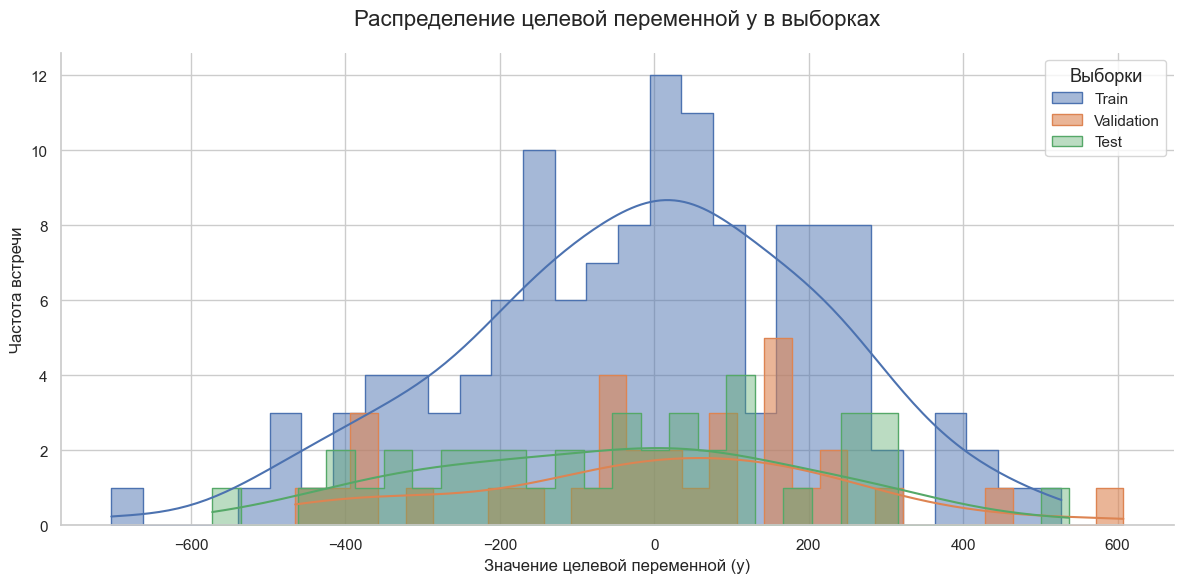

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем премиальный стиль отображения
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(12, 6))

# Строим гистограммы для каждой выборки
# kde=True добавляет линию оценки плотности распределения
sns.histplot(y_train, label='Train', color='#4C72B0', alpha=0.5, kde=True, element="step", bins=30)
sns.histplot(y_val, label='Validation', color='#DD8452', alpha=0.6, kde=True, element="step", bins=30)
sns.histplot(y_test, label='Test', color='#55A868', alpha=0.4, kde=True, element="step", bins=30)

# Настройка осей и заголовка
plt.title('Распределение целевой переменной y в выборках', fontsize=16, pad=20)
plt.xlabel('Значение целевой переменной (y)', fontsize=12)
plt.ylabel('Частота встречи', fontsize=12)

# Добавляем легенду
plt.legend(title="Выборки", title_fontsize='13', fontsize='11')

# Убираем лишние границы для чистоты дизайна
sns.despine()

plt.tight_layout()
plt.show()


Несмотря на разный размер выборок, распределения целевой переменной в Train, Validation и Test схожи по форме, хотя их плотность немного различается. Это говорит о корректном разбиении данных, где каждая выборка отражает общее распределение.

Если бы распределения сильно различались, модель хуже обобщала бы знания. Например, в тестовой выборке могли бы появиться значения, которых не было в обучающей.

## Модель без регуляризации


Прежде чем использовать регуляризацию, создадим базовую модель — линейную регрессию без штрафов. 
Это позволит:
- понять, как модель ведёт себя без ограничений;
- сравнить её поведение и качество с регуляризованными версиями;
- увидеть, как сильно шумовые признаки могут влиять на веса.

Для обучения базовой модели используется только обучающая выборка. Поскольку у линейной регрессии без регуляризации нет гиперпараметров (например, alpha ), отдельный этап подбора параметров через валидационную выборку не проводится.
Однако валидационная выборка всё равно используется для оценки качества модели (в коде ниже предсказания делаются именно на X_val ).

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Обучаем LinearRegression на обучающей выборке
lr = LinearRegression()

lr.fit(X_train, y_train)

# Предсказываем на валидационной выборке
y_pred_lr = lr.predict(X_val)

# Оцениваем качество
mse_lr = mean_squared_error(y_val, y_pred_lr)
r2_lr = r2_score(y_val, y_pred_lr)

print(f"\nLinearRegression → MSE: {mse_lr:.3f}, R2: {r2_lr:.3f}")


LinearRegression → MSE: 20064.504, R2: 0.672


Разберём, что получилось:

- MSE (Mean Squared Error) — среднеквадратичная ошибка. Значение 20064.504 говорит о том, что предсказания модели в среднем сильно отклоняются от настоящих значений y. Высокое значение MSE обусловлено шумностью данных и большим числом признаков, часть из которых неинформативна.
- R² (коэффициент детерминации) — показывает, какую долю дисперсии целевой переменной объясняет модель. Значение 0.672 означает, что модель объясняет около 67.2% изменчивости данных, а оставшиеся ~32.8% — это необъяснённая вариация (ошибка, шум, неучтённые факторы).

Чтобы сравнить, как линейная регрессия без регуляризации распределяет веса и как они соотносятся с истинными коэффициентами, построим один график с двумя наборами столбцов:

- истинные коэффициенты ( true_coefs ) — те, что были заданы при генерации данных;
- коэффициенты модели LinearRegression — обученной на данных без регуляризации.

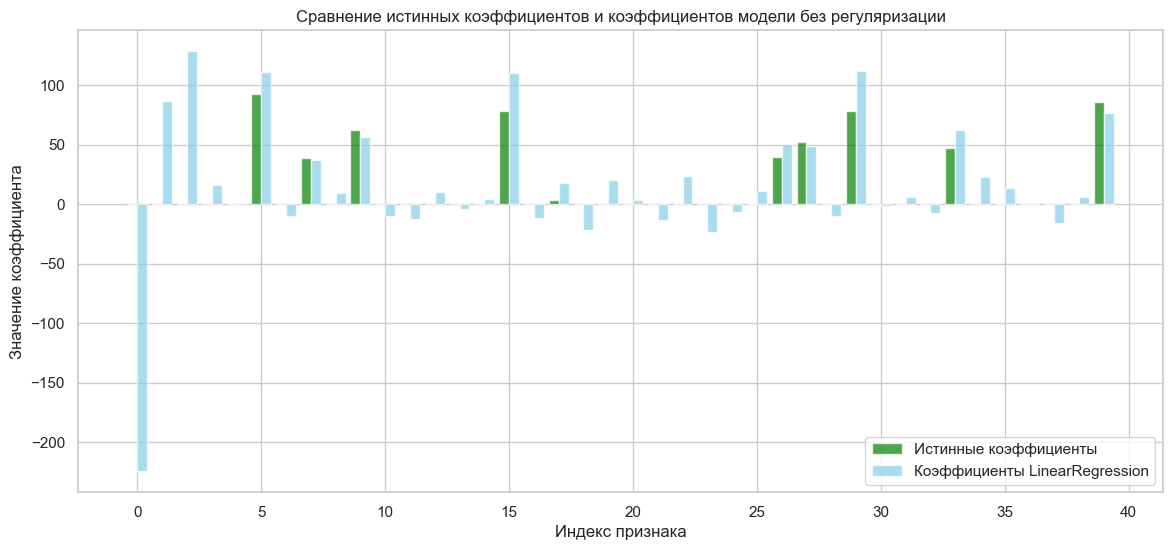

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Создаём массив индексов признаков для оси X
indices = np.arange(len(true_coefs))

plt.figure(figsize=(14, 6))  # Размер графика
width = 0.4  # Ширина столбцов на графике

# Строим столбцы для истинных коэффициентов, смещаем их влево для визуального разделения
plt.bar(indices - width/2, true_coefs, width=width, label='Истинные коэффициенты', color='green', alpha=0.7)

# Строим столбцы для коэффициентов, полученных моделью LinearRegression, смещаем вправо
plt.bar(indices + width/2, lr.coef_, width=width, label='Коэффициенты LinearRegression', color='skyblue', alpha=0.7)

plt.xlabel('Индекс признака')  # Подпись оси X
plt.ylabel('Значение коэффициента')  # Подпись оси Y
plt.title('Сравнение истинных коэффициентов и коэффициентов модели без регуляризации')  # Заголовок графика
plt.legend()  # Отображаем легенду
plt.show()  # Показываем график

Разберём, о чём говорит график:
 - У истинных коэффициентов много нулевых значений — это шумовые признаки. Ненулевые коэффициенты соответствуют важным признакам.
 - Коэффициенты линейной регрессии часто имеют ненулевые значения даже там, где истинные коэффициенты равны нулю, — модель пытается подстроиться под шум.
 - Такое поведение ведёт к переобучению и снижению качества на валидационной выборке.

### L2-регуляризация (Ridge)

L2-регуляризация добавляет к функции потерь штраф за величину коэффициентов модели. Это помогает уменьшить переобучение, сжимая веса признаков к нулю, но при этом не обнуляя их полностью. Таким образом, Ridge сохраняет все признаки, но с уменьшенными коэффициентами.

In [9]:
from sklearn.linear_model import Ridge

# Обучаем модель Ridge с фиксированным alpha
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Предсказание и метрики
y_pred = ridge.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Val MSE: {mse:.3f}, R2: {r2:.3f}")

Val MSE: 18009.807, R2: 0.705


Ошибка MSE уменьшилась (модель лучше приближает реальные значения).
R² вырос (модель объясняет больше дисперсии в данных).

Теперь обучим модель Ridge-регрессии с разными значениями параметра регуляризации alpha. Значение alpha, которое даёт наилучшее качество на валидационной выборке, выбирается как оптимальное.

In [12]:
# Загружаем данные из CSV
df = pd.read_csv("../data/synthetic_regression.csv")

# Разделяем на X и y
X = df.drop(columns="target").values
y = df["target"].values

# Сначала отделяем тестовую выборку (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Из оставшихся 80% берём 20% для валидации
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

alphas = [0.01, 0.1, 1, 10, 50, 100]

best_alpha = None
best_mse = float('inf')
ridge_final = None  # переменная для лучшей модели

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    
    # Оцениваем модель на валидационной выборке
    y_val_pred = ridge.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    
    print(f"Alpha: {alpha:.2f}, Validation MSE: {mse_val:.3f}")
    
    # Сохраняем лучшую модель
    if mse_val < best_mse:
        best_mse = mse_val
        best_alpha = alpha
        ridge_final = ridge  # сохраняем объект модели

print(f"\nЛучший alpha по валидации: {best_alpha}")

# Теперь ridge_final — это обученная модель с оптимальным alpha
y_val_pred = ridge_final.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

print(f"Val MSE: {mse_val:.3f}, Val R²: {r2_val:.3f}")

Alpha: 0.01, Validation MSE: 19998.703
Alpha: 0.10, Validation MSE: 19556.013
Alpha: 1.00, Validation MSE: 18009.807
Alpha: 10.00, Validation MSE: 14896.072
Alpha: 50.00, Validation MSE: 18334.451
Alpha: 100.00, Validation MSE: 25000.234

Лучший alpha по валидации: 10
Val MSE: 14896.072, Val R²: 0.756


### Влияние L2-регуляризации на коэффициенты модели

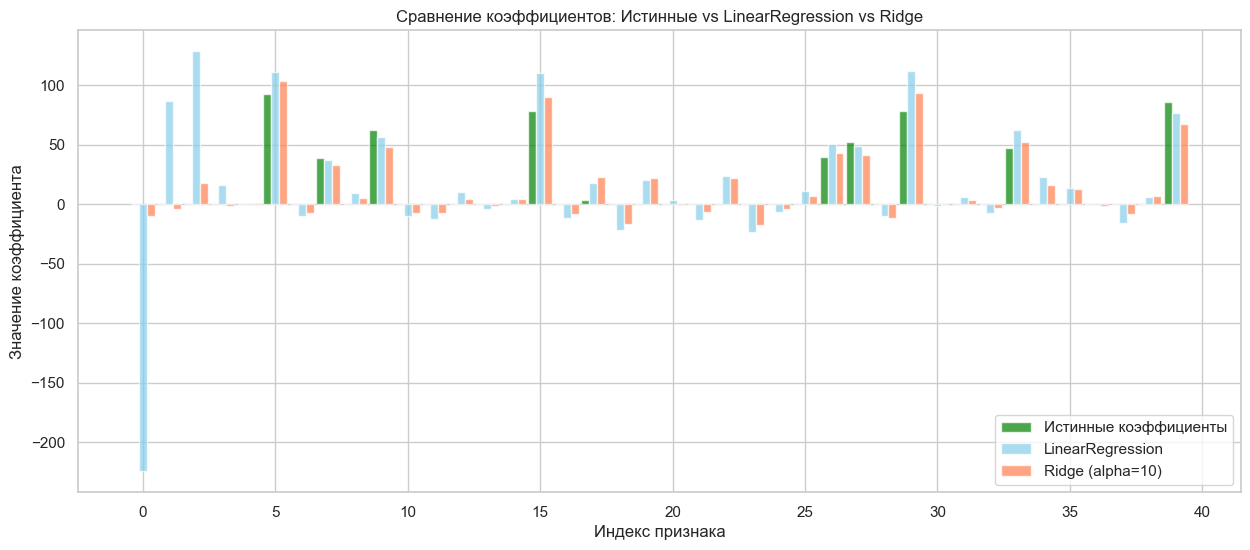

In [13]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.arange(len(true_coefs))  # Индексы признаков
width = 0.3  # Ширина столбцов

plt.figure(figsize=(15, 6))

# Истинные коэффициенты
plt.bar(indices - width, true_coefs, width=width, label='Истинные коэффициенты', color='green', alpha=0.7)

# Коэффициенты LinearRegression (без регуляризации)
plt.bar(indices, lr.coef_, width=width, label='LinearRegression', color='skyblue', alpha=0.7)

# Коэффициенты Ridge (с alpha=10)
plt.bar(indices + width, ridge_final.coef_, width=width, label='Ridge (alpha=10)', color='coral', alpha=0.7)

plt.xlabel('Индекс признака')
plt.ylabel('Значение коэффициента')
plt.title('Сравнение коэффициентов: Истинные vs LinearRegression vs Ridge')
plt.legend()
plt.show()

График помогает понять, что Ridge-регрессия эффективно сдерживает разброс коэффициентов по сравнению с обычной линейной регрессией без регуляризации.

Построим график зависимости нормы коэффициентов Ridge-регрессии от значения параметра alpha.

Измеряя L2-норму вектора коэффициентов, оцениваем общий масштаб всех весов модели: чем больше норма, тем сильнее модель опирается на признаки. При увеличении alpha регуляризация сильнее «сжимает» коэффициенты, снижая их величины, и, как следствие, уменьшается L2-норма.

Таким образом, график наглядно показывает, как регуляризация влияет на размеры весов и их суммарный вклад в предсказания модели:

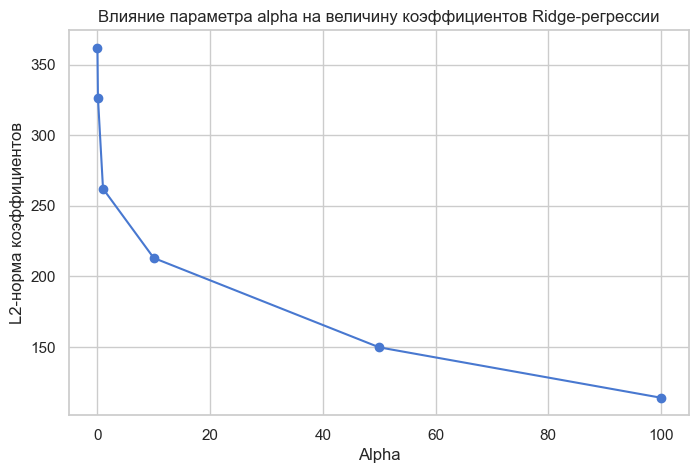

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge

# Мы заранее объявили X_train и y_train
# X_train — это матрица признаков, y_train — целевая переменная

# Задаём список значений параметра регуляризации alpha
alphas = [0.01, 0.1, 1, 10, 50, 100]

# Список для хранения L2-норм коэффициентов модели для каждого alpha
coef_norms = []

# Обучаем Ridge-регрессию для каждого alpha и сохраняем норму коэффициентов
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)  # обучение на обучающей выборке
    coef_norm = np.linalg.norm(ridge.coef_)  # считаем L2-норму коэффициентов
    coef_norms.append(coef_norm)  # сохраняем

# Строим график зависимости нормы коэффициентов от alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, coef_norms, marker='o')
plt.xlabel('Alpha')  # подпись оси X
plt.ylabel('L2-норма коэффициентов')  # подпись оси Y
plt.title('Влияние параметра alpha на величину коэффициентов Ridge-регрессии')
plt.grid(True)
plt.show()

При увеличении значения alpha модель всё сильнее штрафует за большие коэффициенты, поэтому веса становятся «приглушёнными» — их L2-норма уменьшается.

### L1-регуляризация (Lasso)

В отличие от Ridge-регрессии, которая стремится просто «сжать» коэффициенты, Lasso не только уменьшает их, но и может обнулять веса некоторых признаков полностью.

Для L1-регуляризации в sklearn используется класс Lasso, в котором параметр alpha задаёт силу регуляризации.

Обучим модель Lasso-регрессии с фиксированным значением alpha = 1 и сразу оценим её качество на валидационной выборке:

In [15]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import numpy as np

# Загружаем данные из CSV
df = pd.read_csv("../data/synthetic_regression.csv")

# Разделяем на X и y
X = df.drop(columns="target").values
y = df["target"].values

# Сначала отделяем тестовую выборку (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Из оставшихся 80% берём 20% для валидации
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# Обучаем Lasso с фиксированным alpha
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

# Предсказание и оценка
y_pred = lasso.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Val MSE: {mse:.3f}, R2: {r2:.3f}")

Val MSE: 16297.077, R2: 0.733


В приведённом коде реализовано обучение модели Lasso-регрессии с подбором оптимального параметра регуляризации alpha на валидационной выборке, и только финальная модель, показавшая лучшие результаты на валидационной выборке среди всех моделей в уроке, проверяется на тестовой выборке.

In [17]:

# Разделяем на X и y
X = df.drop(columns="target").values
y = df["target"].values

# Сначала отделяем тестовую выборку (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Из оставшихся 80% берём 20% для валидации
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

alphas = [0.01, 0.1, 1, 10, 50, 100]

best_alpha = None
best_mse = float('inf')
lasso_final = None  # переменная для лучшей модели

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    
    # Оцениваем модель на валидационной выборке
    y_val_pred = lasso.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    
    print(f"Alpha: {alpha:.2f}, Validation MSE: {mse_val:.3f}")
    
    # Сохраняем лучшую модель
    if mse_val < best_mse:
        best_mse = mse_val
        best_alpha = alpha
        lasso_final = lasso  # сохраняем объект модели

print(f"\nЛучший alpha по валидации: {best_alpha}")

# Теперь lasso_final — это обученная модель с оптимальным alpha
y_val_pred = lasso_final.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

print(f"Val MSE: {mse_val:.3f}, Val R²: {r2_val:.3f}")

Alpha: 0.01, Validation MSE: 19979.584
Alpha: 0.10, Validation MSE: 19402.894
Alpha: 1.00, Validation MSE: 16297.077
Alpha: 10.00, Validation MSE: 13166.774
Alpha: 50.00, Validation MSE: 43037.964
Alpha: 100.00, Validation MSE: 59399.634

Лучший alpha по валидации: 10
Val MSE: 13166.774, Val R²: 0.784


c:\Projects\yandex-practicum\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.107e+05, tolerance: 6.788e+02
  model = cd_fast.enet_coordinate_descent(
c:\Projects\yandex-practicum\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.434e+03, tolerance: 6.788e+02
  model = cd_fast.enet_coordinate_descent(


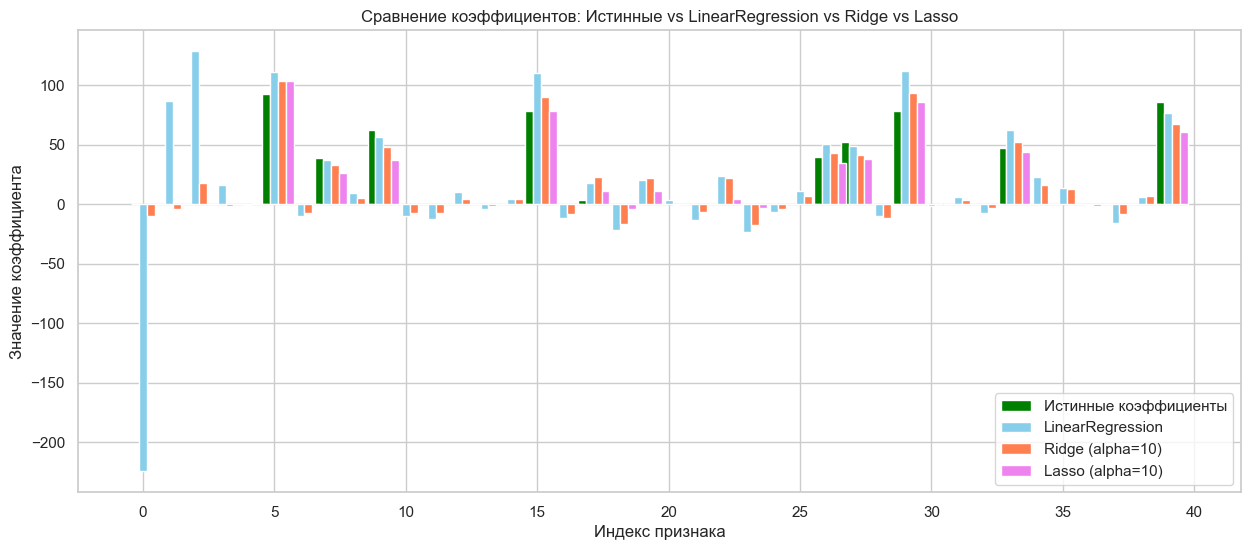

In [23]:
indices = np.arange(len(true_coefs))  # Индексы признаков
width = 0.3  # Ширина столбцов

plt.figure(figsize=(15, 6))

# Истинные коэффициенты
plt.bar(indices - width, true_coefs, width=width, label='Истинные коэффициенты', color='green')

# Коэффициенты LinearRegression (без регуляризации)
plt.bar(indices, lr.coef_, width=width, label='LinearRegression', color='skyblue')

# Коэффициенты Ridge (с alpha=10)
plt.bar(indices + width, ridge_final.coef_, width=width, label='Ridge (alpha=10)', color='coral')

# Коэффициенты Lasso (с alpha=10)
plt.bar(indices + 2*width, lasso_final.coef_, width=width, label='Lasso (alpha=10)', color='violet')

plt.xlabel('Индекс признака')
plt.ylabel('Значение коэффициента')
plt.title('Сравнение коэффициентов: Истинные vs LinearRegression vs Ridge vs Lasso')
plt.legend()
plt.show()

c:\Projects\yandex-practicum\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.107e+05, tolerance: 6.788e+02
  model = cd_fast.enet_coordinate_descent(
c:\Projects\yandex-practicum\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.434e+03, tolerance: 6.788e+02
  model = cd_fast.enet_coordinate_descent(


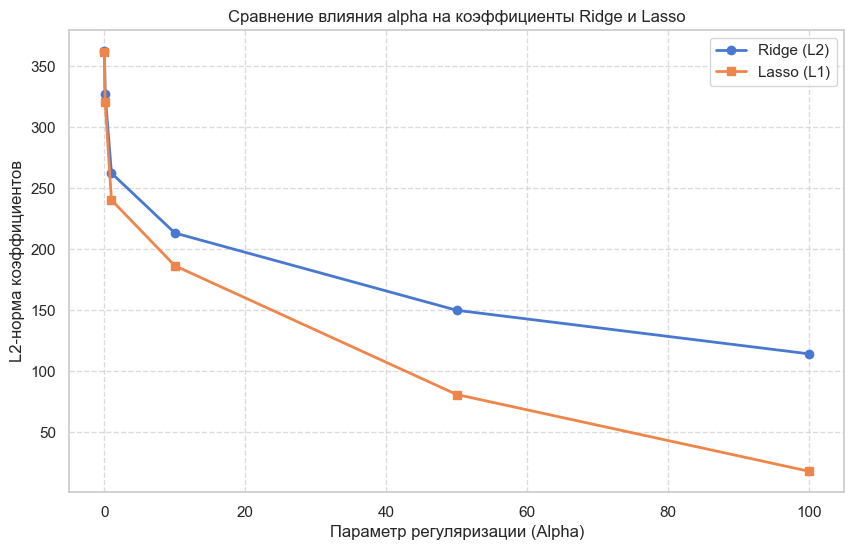

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge, Lasso

# Список значений параметра регуляризации alpha
alphas = [0.01, 0.1, 1, 10, 50, 100]

# Списки для хранения L2-норм коэффициентов
ridge_norms = []
lasso_norms = []

# Обучаем модели для каждого alpha
for alpha in alphas:
    # Ridge-регрессия
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_norms.append(np.linalg.norm(ridge.coef_))
    
    # Lasso-регрессия
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    lasso_norms.append(np.linalg.norm(lasso.coef_))

# Построение графика
plt.figure(figsize=(10, 6))

# График для Ridge
plt.plot(alphas, ridge_norms, marker='o', label='Ridge (L2)', linewidth=2)

# График для Lasso
plt.plot(alphas, lasso_norms, marker='s', label='Lasso (L1)', linewidth=2)

plt.xlabel('Параметр регуляризации (Alpha)')
plt.ylabel('L2-норма коэффициентов')
plt.title('Сравнение влияния alpha на коэффициенты Ridge и Lasso')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Дополнительно: можно сделать логарифмическую шкалу по оси X, 
# если значения alpha сильно разнятся (от 0.01 до 100)
# plt.xscale('log') 

plt.show()


Можно сделать следующие выводы:

- Для Ridge с ростом alpha L2-норма постепенно уменьшается, что означает, что веса становятся меньше по величине, но не обнуляются полностью.
- Для Lasso с увеличением alpha L1-норма также уменьшается, но более резко. Это связано с тем, что Lasso не только сжимает веса, но и обнуляет часть из них, что ведёт к более разреженному решению.

После выбор оптимальной Alpha строим модель

In [25]:
# Разделяем на X и y
X = df.drop(columns="target").values
y = df["target"].values

# Сначала отделяем тестовую выборку (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Из оставшихся 80% берём 20% для валидации
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# Укажем одно значение alpha
alpha = 10

# Истинные нулевые признаки
true_zero_indices = np.where(true_coefs == 0)[0]
print("Истинные нулевые признаки:", true_zero_indices.tolist())
print(f"Всего: {len(true_zero_indices)} признаков\n")

# Обучаем Lasso-модель
lasso = Lasso(alpha=alpha)
lasso.fit(X_train, y_train)
coefs = lasso.coef_

# Найдём признаки, которые модель обнулила
zeroed_by_model = np.where(coefs == 0)[0]
print(f"Lasso (alpha={alpha}) занулил {len(zeroed_by_model)} коэффициентов.")
print("Индексы занулённых признаков:", zeroed_by_model.tolist())

Истинные нулевые признаки: [0, 1, 2, 3, 4, 6, 8, 10, 11, 12, 13, 14, 16, 18, 19, 20, 21, 22, 23, 24, 25, 28, 30, 31, 32, 34, 35, 36, 37, 38]
Всего: 30 признаков

Lasso (alpha=10) занулил 25 коэффициентов.
Индексы занулённых признаков: [0, 1, 2, 3, 4, 6, 8, 10, 11, 12, 13, 14, 16, 20, 21, 24, 25, 28, 30, 31, 32, 34, 36, 37, 38]


## Результаты обучения


| Модель | MSE | R² |
| :--- | :--- | :--- |
| **LinearRegression** | 20064.504 | 0.672 |
| **Ridge (alpha = 10)** | 14896.072 | 0.756 |
| **Lasso (alpha = 10)** | 13166.774 | 0.784 |

Интерпретация метрик:
- LinearRegression (без регуляризации): модель показала более низкое качество обобщения на валидационной выборке.
- Ridge (L2-регуляризация): при оптимальном alpha = 10 модель показала заметное улучшение метрик по сравнению с обычной линейной регрессией.
- Lasso (L1-регуляризация): дала лучшие метрики (низкий MSE и высокий R²).

Регуляризация оказала заметное положительное влияние на качество линейной модели, особенно в условиях, когда данные содержат шум или нерелевантные признаки. Теперь модель обучена корректно и не показывает признаков переобучения.

Пришло время выбрать финальную модель — Lasso (L1-регуляризация) с гиперпараметром ( alpha = 10 ) — и оценить её на тестовой выборке.

In [26]:
# Предсказание и оценка лучшей модели lasso_final при alpha=10
y_pred = lasso_final.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.3f}, R2: {r2:.3f}")

Test MSE: 16818.426, R2: 0.718
